0.014821297505923425 1.401843549936077


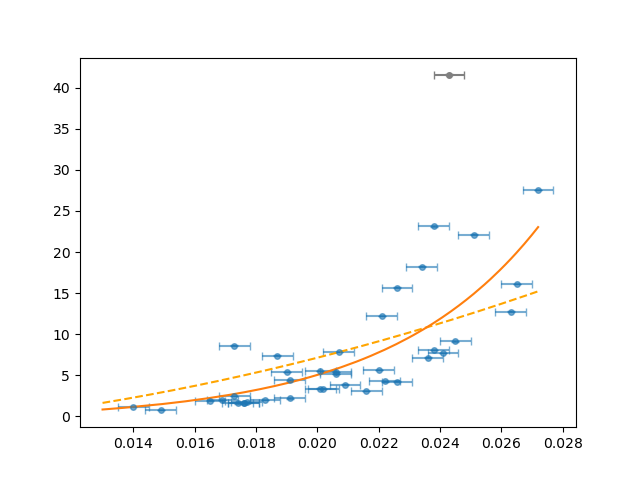

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
%matplotlib widget
plt.close('all')
x = np.array([
    0.0263, 0.0272, 0.0173, 0.0238, 0.0236, 0.0187, 0.0226, 0.0241, 0.0206, 0.0165,
    0.0191, 0.0221, 0.0234, 0.0201, 0.0245, 0.019,  0.0251, 0.0206, 0.0201, 0.0226,
    0.0202, 0.0238, 0.0173, 0.022,  0.0216, 0.0209, 0.014,  0.0183, 0.0207, 0.0265,
    0.0177, 0.0174, 0.0191, 0.0176, 0.0176, 0.0149, 0.0169, 0.0222
])

t = np.array([
    12.73,  27.53,  8.6,    23.13,  7.16,   7.4,    15.67,  7.73,   5.16,   1.9,
    4.4,    12.23,  18.2,   5.53,   9.13,   5.4,    22.1,   5.4,    3.37,   4.21,
    3.33,   8.07,   2.47,   5.63,   3.1,    3.867,  1.2,    2.0,    7.853,  16.118,
    1.7,    1.6,    2.2,    1.63,   1.6,    0.77,   2.0,    4.27
])

x_error=0.0005
t_error=0.04
plt.close('all')
plt.errorbar(x,t,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
plt.errorbar(0.0243,41.57,xerr=x_error,yerr=t_error,fmt='o',zorder=2,color='gray',ms=4,capsize=3)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import k1
from scipy.optimize import curve_fit
r=0.005
fun=lambda x,A:A*(x**2-4*(r)**2)
[A1],_=curve_fit(fun,x,t,t_error)
x_plot=np.linspace(np.min(x)-0.001,np.max(x),1000)
plt.plot(x_plot,fun(x_plot,A1),'--',color='orange')
Lc=2.7*10**(-3)
def cheerios_true(x,A,B):
    t=np.zeros(len(x))
    for j in range(len(x)):
        
        dt=0.001
        t_sim=np.arange(0,120,dt)
        x_sim=np.zeros(len(t_sim))
        v_sim=np.zeros(len(t_sim))
        x_sim[0], v_sim[0] = x[j], 0
        for i in range(len(t_sim)-1):
            if x[j]<2*r:
                t[j]=0
                break
            a=-A*v_sim[i]-B*k1(x_sim[i]/Lc)
            v_sim[i+1]=v_sim[i]+a*dt
            x_sim[i+1]=x_sim[i]+v_sim[i]*dt
            if x_sim[i+1]<=2*r:
                t[j]=t_sim[i+1]
                break
    return t
def error_cheerios(params):
    A,B=params
    t_sim=cheerios_true(x,A,B)
    if A <= 0 or B <= 0: 
        return 1e18 
    error=np.sum(((t_sim-t)/t_error)**2)
    return error
global_bounds=[(0,10),(0,10)]
results=differential_evolution(error_cheerios,global_bounds)
A,B=results.x
t_plot=cheerios_true(x_plot,A,B)
plt.plot(x_plot,t_plot)
print(A,B)

In [3]:
A_1,B_1=A,B
A_1_1=A1
x_plot1=x_plot
t_plot1=t_plot
t_plot1_1=fun(x_plot,A1)
x1=x
t1=t
plt.scatter(x1,t1)
plt.plot(x_plot1,t_plot1)
plt.plot(x_plot1,t_plot1_1)

0.8659337777413425 0.30452542361025525


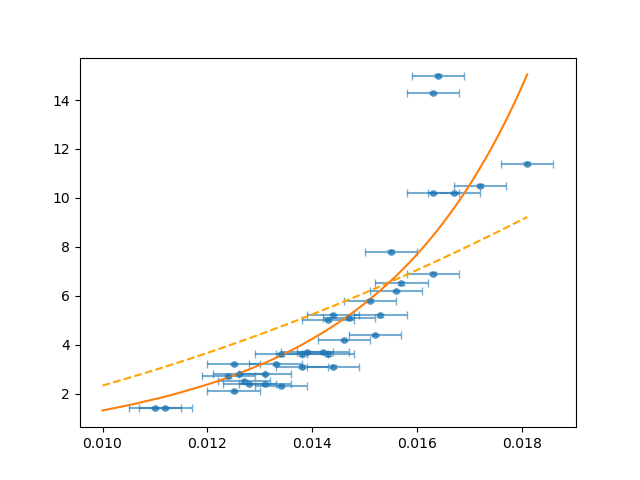

In [66]:
from scipy.optimize import differential_evolution
x=np.array([1.12E-02,1.28E-02,1.25E-02,1.38E-02,1.38E-02,1.42E-02,1.39E-02,1.33E-02,1.56E-02,1.43E-02,1.46E-02,1.51E-02,1.67E-02,1.43E-02,1.31E-02,1.31E-02,1.27E-02,1.53E-02,1.63E-02,1.26E-02,1.24E-02,1.25E-02,1.34E-02,1.47E-02,1.10E-02,1.57E-02,1.34E-02,1.44E-02,1.44E-02,1.64E-02,1.52E-02,1.55E-02,1.63E-02,1.81E-02,1.63E-02,1.72E-02])
t=np.array([1.4,2.4,2.1,3.1,3.6,3.7,3.7,3.2,6.2,5,4.2,5.8,10.2,3.6,2.4,2.8,2.5,5.2,6.9,2.8,2.7,3.2,3.6,5.1,1.4,6.5,2.3,3.1,5.2,15,4.4,7.8,10.2,11.4,14.3,10.5])
plt.close('all')
plt.scatter(x,t)


x_error=0.0005
t_error=0.05
plt.close('all')
plt.errorbar(x,t,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import k1
from scipy.optimize import curve_fit
r=0.0024
fun=lambda x,A:A*(x**2-4*(r)**2)
[A1],_=curve_fit(fun,x,t,t_error)
x_plot=np.linspace(np.min(x)-0.001,np.max(x),1000)
plt.plot(x_plot,fun(x_plot,A1),'--',color='orange')
Lc=2.7*10**(-3)
def cheerios_true(x,A,B):
    t=np.zeros(len(x))
    for j in range(len(x)):
        
        dt=0.001
        t_sim=np.arange(0,100,dt)
        x_sim=np.zeros(len(t_sim))
        v_sim=np.zeros(len(t_sim))
        x_sim[0], v_sim[0] = x[j], 0
        for i in range(len(t_sim)-1):
            if x[j]<2*r:
                t[j]=0
                break
            a=-A*v_sim[i]-B*k1(x_sim[i]/Lc)
            v_sim[i+1]=v_sim[i]+a*dt
            x_sim[i+1]=x_sim[i]+v_sim[i]*dt
            if x_sim[i+1]<=2*r:
                t[j]=t_sim[i+1]
                break
    return t
def error_cheerios(params):
    A,B=params
    t_sim=cheerios_true(x,A,B)
    if A <= 0 or B <= 0: 
        return 1e18 
    error=np.sum(((t_sim-t)/t_error)**2)
    return error
global_bounds=[(0,10),(0,10)]

results=differential_evolution(error_cheerios,global_bounds)
A,B=results.x
t_plot=cheerios_true(x_plot,A,B)
plt.plot(x_plot,t_plot)
print(A,B)

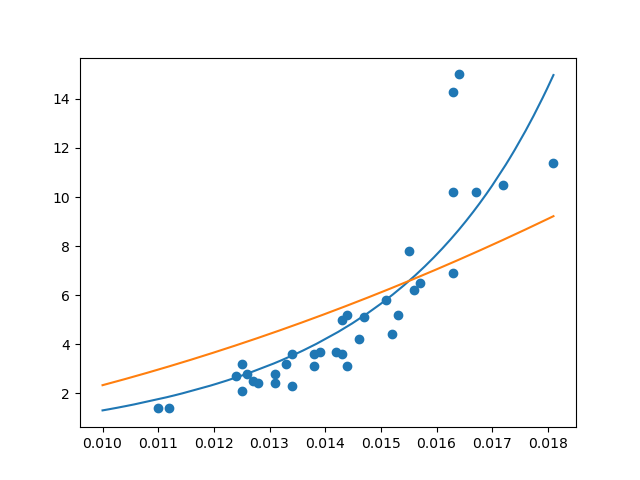

In [5]:
A_2,B_2=A,B
A_1_2=A1
x_plot2=x_plot
t_plot2=t_plot
t_plot1_2=fun(x_plot,A1)
x2=x
t2=t
plt.close('all')
plt.scatter(x2,t2)
plt.plot(x_plot2,t_plot2)
plt.plot(x_plot2,t_plot1_2)

0.004619200529985434 0.003941314009174515


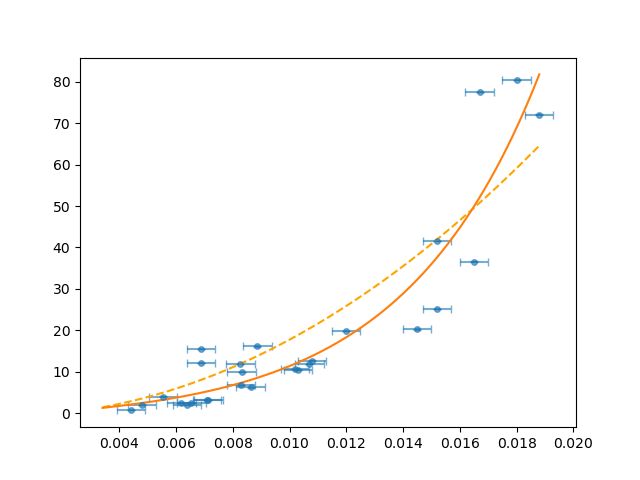

In [68]:
plt.close('all')
x=np.array([4.41E-03,6.88E-03,8.27E-03,5.55E-03,4.79E-03,6.19E-03,6.87E-03,6.54E-03,8.31E-03,8.87E-03,8.29E-03,8.63E-03,7.10E-03,7.14E-03,6.38E-03,1.07E-02,1.08E-02,1.03E-02,1.20E-02,1.02E-02,1.52E-02,1.80E-02,1.45E-02,1.65E-02,1.88E-02,1.67E-02,1.52E-02])
t=np.array([0.7,15.5,11.87,4,1.9,2.4,12.1,2.5,9.9,16.1,6.8,6.2,3.1,3.1,1.9,11.8,12.7,10.4,19.8,10.7,25.2,80.5,20.2,36.6,72.1,77.6,41.5])
x_error=0.0005
t_error=0.05
plt.close('all')
plt.errorbar(x,t,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import k1
from scipy.optimize import curve_fit
r=0.001
fun=lambda x,A:A*(x**2-4*(r)**2)
[A1],_=curve_fit(fun,x,t,t_error)
x_plot=np.linspace(np.min(x)-0.001,np.max(x),1000)
plt.plot(x_plot,fun(x_plot,A1),'--',color='orange')
Lc=2.7*10**(-3)
def cheerios_true(x,A,B):
    t=np.zeros(len(x))
    for j in range(len(x)):
        
        dt=0.001
        t_sim=np.arange(0,100,dt)
        x_sim=np.zeros(len(t_sim))
        v_sim=np.zeros(len(t_sim))
        x_sim[0], v_sim[0] = x[j], 0
        for i in range(len(t_sim)-1):
            if x[j]<2*r:
                t[j]=0
                break
            a=-A*v_sim[i]-B*k1(x_sim[i]/Lc)
            v_sim[i+1]=v_sim[i]+a*dt
            x_sim[i+1]=x_sim[i]+v_sim[i]*dt
            if x_sim[i+1]<=2*r:
                t[j]=t_sim[i+1]
                break
    return t
def error_cheerios(params):
    A,B=params
    t_sim=cheerios_true(x,A,B)
    if A <= 0 or B <= 0: 
        return 1e18 
    error=np.sum(((t_sim-t)/t_error)**2)
    return error
global_bounds=[(0,10),(0,10)]

results=differential_evolution(error_cheerios,global_bounds)
A,B=results.x
t_plot=cheerios_true(x_plot,A,B)
plt.plot(x_plot,t_plot)
print(A,B)

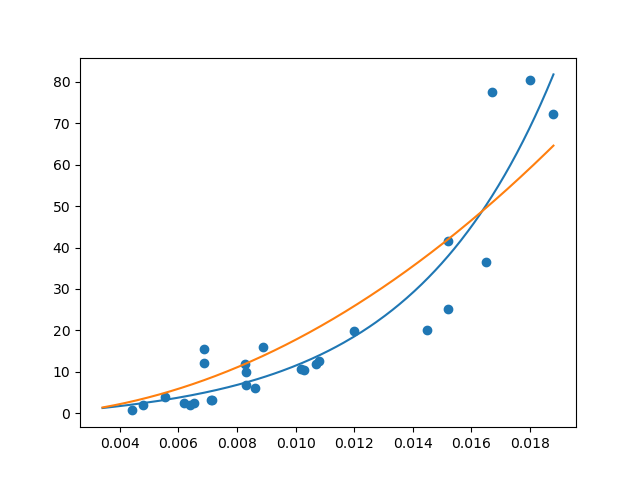

In [7]:
A_3,B_3=A,B
A_1_3=A1
x_plot3=x_plot
t_plot3=t_plot
t_plot1_3=fun(x_plot,A1)
x3=x
t3=t
plt.close('all')
plt.scatter(x3,t3)
plt.plot(x_plot3,t_plot3)
plt.plot(x_plot3,t_plot1_3)

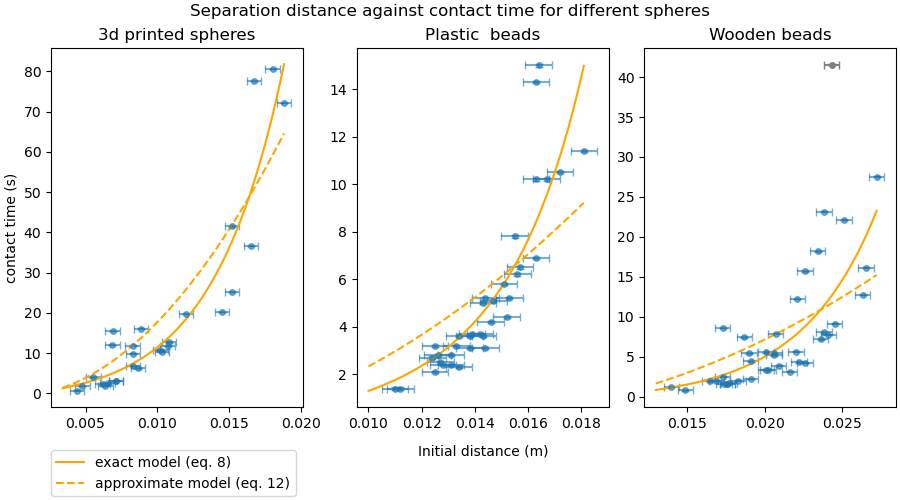

In [64]:
plt.close('all')
fig,ax=plt.subplots(1,3,figsize=(9,5),constrained_layout=True)
ax1,ax2,ax3=ax[0],ax[1],ax[2]
ax3.errorbar(x1,t1,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
ax3.errorbar(0.0243,41.57,xerr=x_error,yerr=t_error,fmt='o',zorder=2,color='gray',ms=4,capsize=3)
ax3.plot(x_plot1,t_plot1,color='orange')
ax3.plot(x_plot1,t_plot1_1,'--',color='orange')
ax2.errorbar(x2,t2,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
ax2.plot(x_plot2,t_plot2,color='orange')
ax2.plot(x_plot2,t_plot1_2,'--',color='orange')
ax1.errorbar(x3,t3,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
ax1.plot(x_plot3,t_plot3,color='orange',label='exact model (eq. 8)')
ax1.plot(x_plot3,t_plot1_3,'--',color='orange',label='approximate model (eq. 12)')
ax1.set_title('3d printed spheres')
ax2.set_title('Plastic  beads')
ax3.set_title('Wooden beads')
ax2.set_xlabel('Initial distance (m)',labelpad=10)
ax1.set_ylabel('contact time (s)')
ax1.legend(bbox_to_anchor=(1,-0.1))

plt.suptitle('Separation distance against contact time for different spheres')
plt.show()